In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [2]:
# Create simple sample network traffic dataset
np.random.seed(42)

dates = pd.date_range(start='2026-01-01', periods=100, freq='H')
traffic = np.random.normal(loc=120, scale=20, size=100).astype(int)

# Add artificial DDoS-like spikes
traffic[40] = 650
traffic[70] = 720

data = pd.DataFrame({
    'timestamp': dates,
    'traffic_volume': traffic
})

data.to_csv('network_traffic.csv', index=False)
data.head()


,timestamp,traffic_volume
0,2026-01-01 00:00:00,129
1,2026-01-01 01:00:00,117
2,2026-01-01 02:00:00,132
3,2026-01-01 03:00:00,150
4,2026-01-01 04:00:00,115


In [3]:
data = pd.read_csv('network_traffic.csv')
data['timestamp'] = pd.to_datetime(data['timestamp'])
data.set_index('timestamp', inplace=True)

data.head()

,traffic_volume
timestamp,
2026-01-01 00:00:00,129
2026-01-01 01:00:00,117
2026-01-01 02:00:00,132
2026-01-01 03:00:00,150
2026-01-01 04:00:00,115


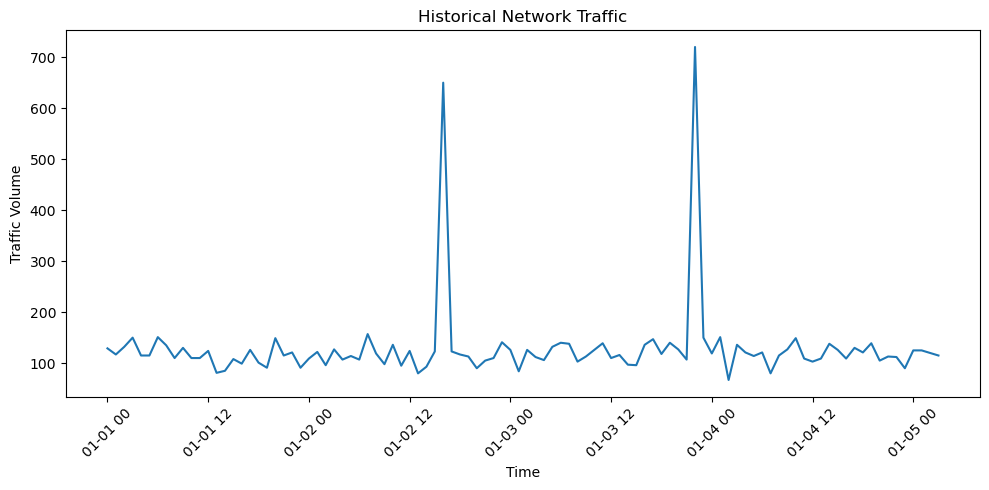

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['traffic_volume'])
plt.title('Historical Network Traffic')
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
model = ARIMA(data['traffic_volume'], order=(2, 1, 2))
model_fit = model.fit()

C:\Users\siris\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\siris\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
C:\Users\siris\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)


In [6]:
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

future_dates = pd.date_range(
    start=data.index[-1] + pd.Timedelta(hours=1),
    periods=forecast_steps,
    freq='H'
)

forecast_df = pd.DataFrame({
    'timestamp': future_dates,
    'forecasted_traffic': forecast.values
})

forecast_df

,timestamp,forecasted_traffic
0,2026-01-05 04:00:00,128.195547
1,2026-01-05 05:00:00,128.893391
2,2026-01-05 06:00:00,128.189031
3,2026-01-05 07:00:00,128.685807
4,2026-01-05 08:00:00,128.338679
5,2026-01-05 09:00:00,128.581168
6,2026-01-05 10:00:00,128.411777
7,2026-01-05 11:00:00,128.530106
8,2026-01-05 12:00:00,128.447447
9,2026-01-05 13:00:00,128.505188


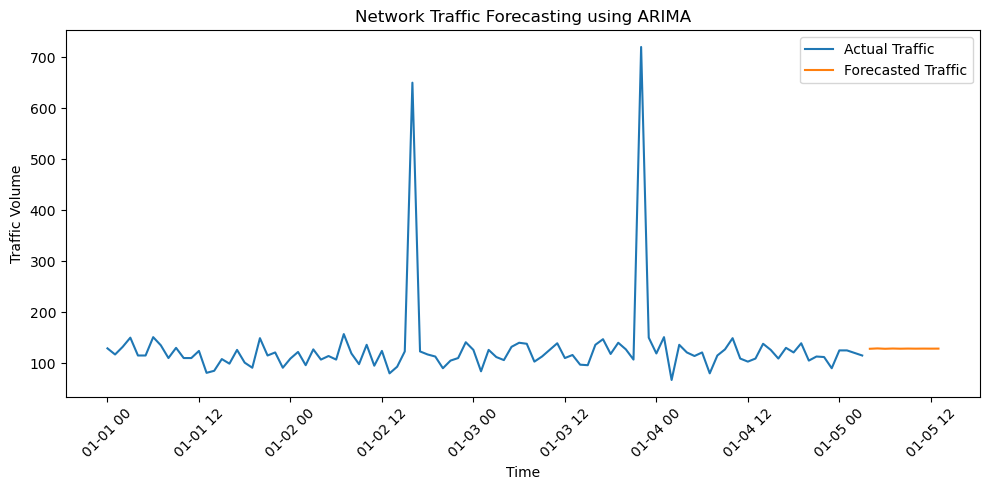

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['traffic_volume'], label='Actual Traffic')
plt.plot(forecast_df['timestamp'], forecast_df['forecasted_traffic'], label='Forecasted Traffic')
plt.title('Network Traffic Forecasting using ARIMA')
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
threshold = 500

forecast_df['status'] = forecast_df['forecasted_traffic'].apply(
    lambda x: 'Possible DDoS Attack' if x > threshold else 'Normal Traffic'
)

forecast_df

,timestamp,forecasted_traffic,status
0,2026-01-05 04:00:00,128.195547,Normal Traffic
1,2026-01-05 05:00:00,128.893391,Normal Traffic
2,2026-01-05 06:00:00,128.189031,Normal Traffic
3,2026-01-05 07:00:00,128.685807,Normal Traffic
4,2026-01-05 08:00:00,128.338679,Normal Traffic
5,2026-01-05 09:00:00,128.581168,Normal Traffic
6,2026-01-05 10:00:00,128.411777,Normal Traffic
7,2026-01-05 11:00:00,128.530106,Normal Traffic
8,2026-01-05 12:00:00,128.447447,Normal Traffic
9,2026-01-05 13:00:00,128.505188,Normal Traffic


In [9]:
for _, row in forecast_df.iterrows():
    print(row['timestamp'], '-', row['status'])

2026-01-05 04:00:00 - Normal Traffic
2026-01-05 05:00:00 - Normal Traffic
2026-01-05 06:00:00 - Normal Traffic
2026-01-05 07:00:00 - Normal Traffic
2026-01-05 08:00:00 - Normal Traffic
2026-01-05 09:00:00 - Normal Traffic
2026-01-05 10:00:00 - Normal Traffic
2026-01-05 11:00:00 - Normal Traffic
2026-01-05 12:00:00 - Normal Traffic
2026-01-05 13:00:00 - Normal Traffic
